# EDA

# 1. First Look at Data

In [59]:
# First Look at the Cleaned Adult Income Dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', None)

print('Setup complete.')

Setup complete.


## Section 1 — Loading the Data & Peeking at Rows

This section loads the cleaned Adult Income dataset and previews several rows from the beginning, end, and a random sample of the data. This helps confirm that the dataset was imported correctly and that the structure is consistent across the file.

In [60]:
df_eda = pd.read_excel('adult_cleaned.xlsx')
df_eda.head()

,age,workclass,education,marital_status,occupation,relationship,race,sex,hours_per_week,native_country,capital_gain_flag,capital_loss_flag,income
0,39,state-gov,bachelors,never-married,adm-clerical,not-in-family,white,male,40,united-states,1,0,<=50k
1,50,self-emp-not-inc,bachelors,married-civ-spouse,exec-managerial,husband,white,male,13,united-states,0,0,<=50k
2,38,private,hs-grad,divorced,handlers-cleaners,not-in-family,white,male,40,united-states,0,0,<=50k
3,53,private,11th,married-civ-spouse,handlers-cleaners,husband,black,male,40,united-states,0,0,<=50k
4,28,private,bachelors,married-civ-spouse,prof-specialty,wife,black,female,40,cuba,0,0,<=50k


In [61]:
# Check the last few rows to avoid relying only on the first records
df_eda.tail()

,age,workclass,education,marital_status,occupation,relationship,race,sex,hours_per_week,native_country,capital_gain_flag,capital_loss_flag,income
32529,27,private,assoc-acdm,married-civ-spouse,tech-support,wife,white,female,38,united-states,0,0,<=50k
32530,40,private,hs-grad,married-civ-spouse,machine-op-inspct,husband,white,male,40,united-states,0,0,>50k
32531,58,private,hs-grad,widowed,adm-clerical,unmarried,white,female,40,united-states,0,0,<=50k
32532,22,private,hs-grad,never-married,adm-clerical,own-child,white,male,20,united-states,0,0,<=50k
32533,52,self-emp-inc,hs-grad,married-civ-spouse,exec-managerial,wife,white,female,40,united-states,1,0,>50k


In [62]:
# View a random sample of the dataset
df_eda.sample(5, random_state=42)

,age,workclass,education,marital_status,occupation,relationship,race,sex,hours_per_week,native_country,capital_gain_flag,capital_loss_flag,income
10376,46,local-gov,assoc-acdm,married-civ-spouse,protective-serv,husband,white,male,49,united-states,0,0,>50k
6014,65,private,hs-grad,married-civ-spouse,sales,husband,white,male,40,united-states,1,0,>50k
29312,27,private,some-college,never-married,adm-clerical,unmarried,white,female,60,united-states,0,0,<=50k
7653,37,private,assoc-acdm,married-civ-spouse,other-service,wife,white,female,25,united-states,0,0,<=50k
18134,74,self-emp-not-inc,assoc-voc,married-civ-spouse,sales,husband,white,male,20,united-states,0,0,>50k


## Section 2 — How Big Is It?

In [63]:
print('Rows, columns:', df_eda.shape)

print('\nColumn names:')
print(df_eda.columns.tolist())

Rows, columns: (32534, 13)

Column names:
['age', 'workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'hours_per_week', 'native_country', 'capital_gain_flag', 'capital_loss_flag', 'income']


## Section 3 — Column Types and Missing Data

In [64]:
# Check data types and non-null counts
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32534 entries, 0 to 32533
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   age                32534 non-null  int64 
 1   workclass          32534 non-null  object
 2   education          32534 non-null  object
 3   marital_status     32534 non-null  object
 4   occupation         32534 non-null  object
 5   relationship       32534 non-null  object
 6   race               32534 non-null  object
 7   sex                32534 non-null  object
 8   hours_per_week     32534 non-null  int64 
 9   native_country     32534 non-null  object
 10  capital_gain_flag  32534 non-null  int64 
 11  capital_loss_flag  32534 non-null  int64 
 12  income             32534 non-null  object
dtypes: int64(4), object(9)
memory usage: 3.2+ MB


In [65]:
# Confirm that the cleaned dataset has no missing values

missing_summary = pd.DataFrame({
    'n_missing': df_eda.isnull().sum(),
}).sort_values('n_missing', ascending=False)

missing_summary

,n_missing
age,0
workclass,0
education,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0
hours_per_week,0
native_country,0


## Section 4 — Column Cardinality and Unique Value Analysis

This section examines the number of unique values in each column. Cardinality helps identify binary variables, high-cardinality categorical variables, and variables that may require careful visualisation.

In [66]:
# Count unique values in each column

unique_summary = pd.DataFrame({
    'dtype': df_eda.dtypes,
    'n_unique': df_eda.nunique(),
    'example_values': [
        df_eda[col].dropna().unique()[:5].tolist()
        for col in df_eda.columns
    ]
})

unique_summary

,dtype,n_unique,example_values
age,int64,58,"[39, 50, 38, 53, 28]"
workclass,object,8,"[state-gov, self-emp-not-inc, private, federal..."
education,object,16,"[bachelors, hs-grad, 11th, masters, 9th]"
marital_status,object,7,"[never-married, married-civ-spouse, divorced, ..."
occupation,object,14,"[adm-clerical, exec-managerial, handlers-clean..."
relationship,object,6,"[not-in-family, husband, wife, own-child, unma..."
race,object,5,"[white, black, asian-pac-islander, amer-indian..."
sex,object,2,"[male, female]"
hours_per_week,int64,70,"[40, 13, 16, 45, 50]"
native_country,object,41,"[united-states, cuba, jamaica, india, mexico]"


### Analysis
The dataset contains both low-cardinality variables, such as `sex`, `income`, `capital_gain_flag`, and `capital_loss_flag`, and higher-cardinality variables, such as `native_country`, `occupation`, and `education`. This suggests that some categorical variables may need ordered bar charts or grouping in later analysis.

## Section 5 — Numeric vs. Categorical

In [67]:
# Separate numeric and categorical columns

numeric_cols = df_eda.select_dtypes(include='number').columns.tolist()
categorical_cols = df_eda.select_dtypes(include='object').columns.tolist()

print('Numeric columns:')
print(numeric_cols)

print('\nCategorical columns:')
print(categorical_cols)

Numeric columns:
['age', 'hours_per_week', 'capital_gain_flag', 'capital_loss_flag']

Categorical columns:
['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country', 'income']


In [68]:
# Summary statistics for numeric variables

df_eda.describe().round(2)

,age,hours_per_week,capital_gain_flag,capital_loss_flag
count,32534.00,32534.00,32534.00,32534.00
mean,38.53,40.39,0.08,0.05
std,13.48,11.94,0.28,0.21
min,17.00,8.00,0.00,0.00
25%,28.00,40.00,0.00,0.00
50%,37.00,40.00,0.00,0.00
75%,48.00,45.00,0.00,0.00
max,74.00,80.00,1.00,1.00


In [69]:
# Summary statistics for categorical variables

df_eda.describe(include="object")

,workclass,education,marital_status,occupation,relationship,race,sex,native_country,income
count,32534,32534,32534,32534,32534,32534,32534,32534,32534
unique,8,16,7,14,6,5,2,41,2
top,private,hs-grad,married-civ-spouse,prof-specialty,husband,white,male,united-states,<=50k
freq,24506,10493,14968,5978,13185,27792,21773,29732,24696


# 2. Univariate Analysis

## Section 1 — Univariate Analysis of Age

In [72]:
# Central tendency statistics for age

summary = pd.DataFrame({
    'Mean':[df_eda['age'].mean()],
    'Median':[df_eda['age'].median()],
    'Std':[df_eda['age'].std()],
    'Min':[df_eda['age'].min()],
    'Max':[df_eda['age'].max()]
})

summary.round(2)

,Mean,Median,Std,Min,Max
0,38.53,37.0,13.48,17,74


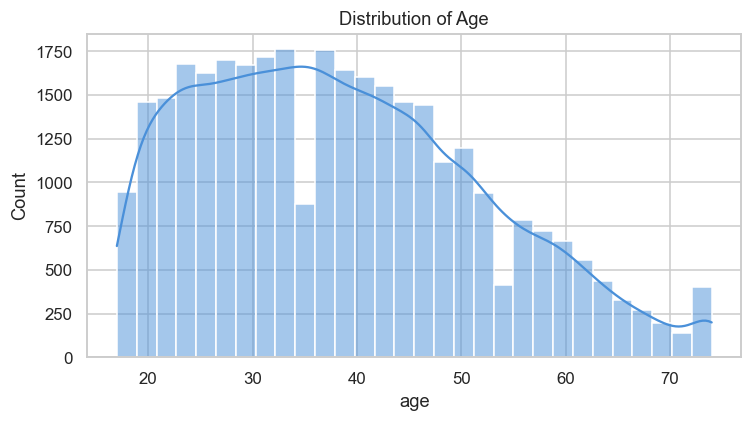

In [73]:
# Histogram

plt.figure(figsize=(7,4))

sns.histplot(
    data=df_eda,
    x='age',
    bins=30,
    kde=True,
    color='#4a90d9'
)

plt.title('Distribution of Age')
plt.tight_layout()
plt.show()

### Analysis

The age distribution is approximately bimodal, with two noticeable peaks around 30–35 years and 38–40 years. Most individuals are concentrated between 20 and 50 years old, indicating that the dataset mainly consists of working-age adults.

A distinctive dip appears around age 35, separating the two peaks. This pattern suggests that the dataset may contain multiple subgroups with different age structures rather than a single homogeneous population.

The distribution is positively skewed (right-skewed), as the frequency gradually decreases after age 40 while extending toward older ages. Individuals above 60 years old represent a relatively small proportion of the dataset. Overall, age is not normally distributed and exhibits both bimodal and right-skewed characteristics.

In [74]:
# Calculate IQR and detect outliers for age

Q1 = df_eda['age'].quantile(0.25)
Q3 = df_eda['age'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_eda[
    (df_eda['age'] < lower) |
    (df_eda['age'] > upper)
]

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound: {lower}")
print(f"Upper Bound: {upper}")
print(f"Number of Outliers: {len(outliers)}")
print(f"Percentage of Outliers: {len(outliers)/len(df_eda)*100:.2f}%")

Q1: 28.0
Q3: 48.0
IQR: 20.0
Lower Bound: -2.0
Upper Bound: 78.0
Number of Outliers: 0
Percentage of Outliers: 0.00%


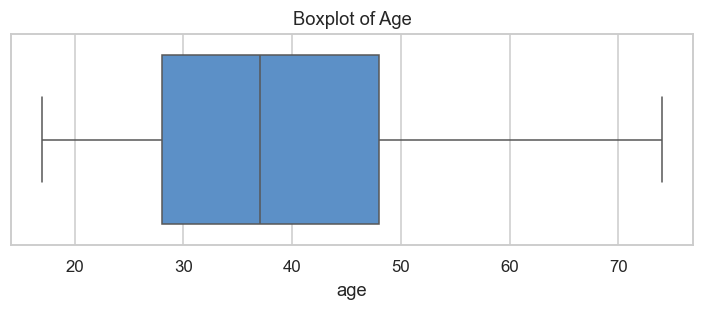

In [75]:
# Boxplot and outlier detection

plt.figure(figsize=(8,2.5))

sns.boxplot(
    x=df_eda['age'],
    color='#4a90d9'
)

plt.title('Boxplot of Age')
plt.show()


### Analysis

The boxplot shows that the median age is approximately 37 years, indicating that half of the individuals in the dataset are younger than 37 and half are older.

The middle 50% of observations lie roughly between 28 and 47 years old, suggesting that most individuals belong to the prime working-age population. The right whisker is considerably longer than the left whisker, confirming the positive skewness observed in the histogram.

No apparent outliers are detected according to the 1.5 × IQR rule, indicating that the age values are relatively well distributed and do not contain unusually extreme observations. The absence of outliers suggests that the dataset has a reasonable age range and good overall data quality.


## Section 2 — Univariate Analysis of Hours Worked Per Week

In [76]:
# Central tendency statistics for hours_per_week

summary = pd.DataFrame({
    'Mean':[df_eda['hours_per_week'].mean()],
    'Median':[df_eda['hours_per_week'].median()],
    'Std':[df_eda['hours_per_week'].std()],
    'Min':[df_eda['hours_per_week'].min()],
    'Max':[df_eda['hours_per_week'].max()]
})

summary.round(2)

,Mean,Median,Std,Min,Max
0,40.39,40.0,11.94,8,80


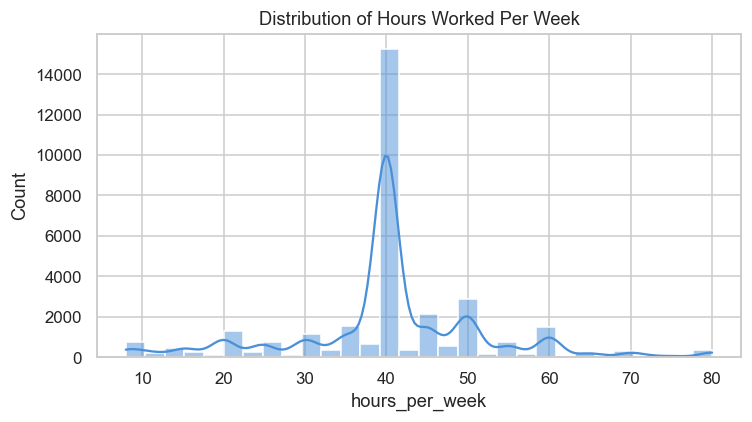

In [77]:
# Histogram

plt.figure(figsize=(7,4))

sns.histplot(
    data=df_eda,
    x='hours_per_week',
    bins=30,
    kde=True,
    color='#4a90d9'
)

plt.title('Distribution of Hours Worked Per Week')
plt.tight_layout()
plt.show()

### Analysis

The distribution of hours worked per week is highly concentrated around 40 hours, forming a very prominent peak. This indicates that the majority of individuals in the dataset follow a standard full-time work schedule.

In addition to the main peak, several smaller peaks can be observed around 20, 50, and 60 hours per week, suggesting the presence of multiple working patterns, such as part-time workers and employees with longer working hours. The distribution also exhibits a noticeable right tail extending toward 80 hours, indicating that a small proportion of individuals work substantially more than the standard full-time schedule.

Overall, the variable is not normally distributed and displays both multimodal and right-skewed characteristics, reflecting the diversity of employment arrangements represented in the dataset.

In [78]:
# Calculate IQR and detect outliers for hours_per_week

Q1 = df_eda['hours_per_week'].quantile(0.25)
Q3 = df_eda['hours_per_week'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_eda[
    (df_eda['hours_per_week'] < lower) |
    (df_eda['hours_per_week'] > upper)
]

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound: {lower}")
print(f"Upper Bound: {upper}")
print(f"Number of Outliers: {len(outliers)}")
print(f"Percentage of Outliers: {len(outliers)/len(df_eda)*100:.2f}%")

Q1: 40.0
Q3: 45.0
IQR: 5.0
Lower Bound: 32.5
Upper Bound: 52.5
Number of Outliers: 9001
Percentage of Outliers: 27.67%


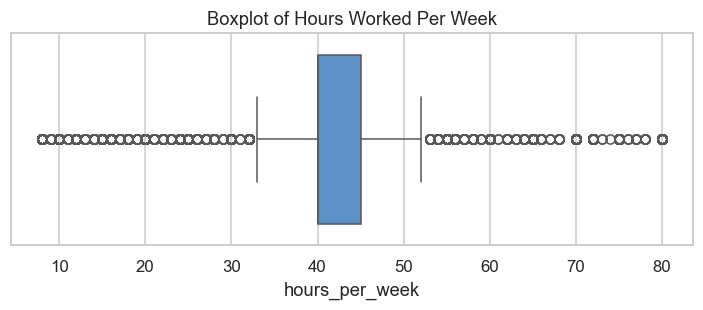

In [79]:
# Boxplot and outlier detection

plt.figure(figsize=(8,2.5))

sns.boxplot(
    x=df_eda['hours_per_week'],
    color='#4a90d9'
)

plt.title('Boxplot of Hours Worked Per Week')
plt.show()

### Analysis

The boxplot shows that the median age is approximately 37 years, while the middle 50% of observations are concentrated between 28 and 48 years old (IQR = 20). This indicates that most individuals in the dataset belong to the prime working-age population.

Using the 1.5 × IQR rule, no outliers were detected. The calculated lower and upper bounds are -2 and 78 years, respectively, and all observed age values fall within this range. This suggests that the age variable is well distributed and does not contain unusually extreme observations.

The absence of outliers is consistent with the histogram, where the age values span a reasonable range without isolated extreme cases. Overall, the age variable demonstrates good data quality and provides a representative view of the workforce population.

## Section 3 — Univariate Analysis of Workclass

In [80]:
# Frequency table for workclass

freq_table = pd.DataFrame({
    'count': df_eda['workclass'].value_counts(),
    'percentage': (df_eda['workclass'].value_counts(normalize=True)*100).round(2)
})

freq_table.head(15)

,count,percentage
workclass,,
private,24506,75.32
self-emp-not-inc,2540,7.81
local-gov,2093,6.43
state-gov,1298,3.99
self-emp-inc,1116,3.43
federal-gov,960,2.95
without-pay,14,0.04
never-worked,7,0.02


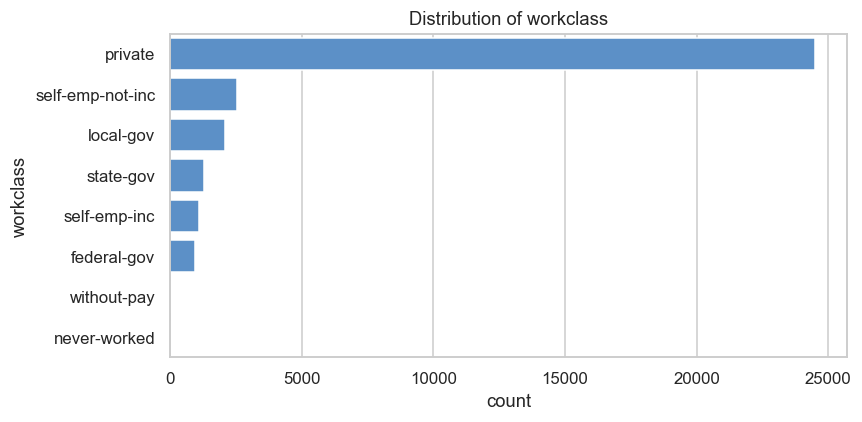

In [81]:
plt.figure(figsize=(8,4))

order = df_eda['workclass'].value_counts().index

sns.countplot(
    data=df_eda,
    y='workclass',
    order=order,
    color='#4a90d9'
)

plt.title('Distribution of workclass')
plt.tight_layout()
plt.show()

### Analysis

The distribution of workclass is highly imbalanced. The majority of individuals (75.32%) belong to the Private sector, making it by far the most common employment category in the dataset.

Self-employed individuals without incorporated businesses account for 7.81% of the sample, while local government, state government, federal government, and self-employed incorporated workers each represent relatively small proportions. The categories Without-pay (0.04%) and Never-worked (0.02%) contain only a handful of observations.

## Section 4 — Univariate Analysis of Education

In [82]:
# Frequency table for education

freq_table = pd.DataFrame({
    'count': df_eda['education'].value_counts(),
    'percentage': (df_eda['education'].value_counts(normalize=True)*100).round(2)
})

freq_table.head(15)

,count,percentage
education,,
hs-grad,10493,32.25
some-college,7281,22.38
bachelors,5352,16.45
masters,1722,5.29
assoc-voc,1382,4.25
11th,1175,3.61
assoc-acdm,1067,3.28
10th,933,2.87
7th-8th,645,1.98


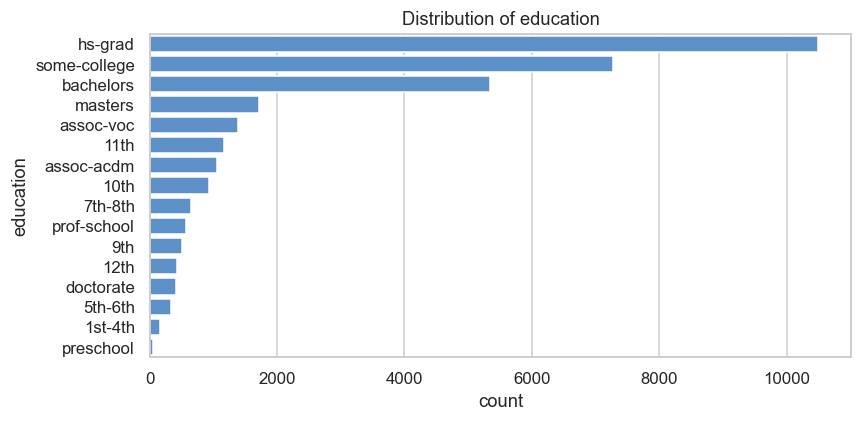

In [83]:
plt.figure(figsize=(8,4))

order = df_eda['education'].value_counts().index

sns.countplot(
    data=df_eda,
    y='education',
    order=order,
    color='#4a90d9'
)

plt.title('Distribution of education')
plt.tight_layout()
plt.show()

### Analysis

The education variable shows substantial variation across educational attainment levels. The largest group is HS-grad, accounting for 32.25% of all individuals, followed by Some-college (22.38%) and Bachelors (16.45%). Together, these three categories represent more than 70% of the dataset.

Higher educational qualifications such as Masters (5.29%), Professional School (1.77%), and Doctorate (1.27%) are comparatively less common. Lower education levels, including elementary and middle school categories, account for only a small proportion of observations.

## Section 5 — Univariate Analysis of Marital_status

In [84]:
# Frequency table for marital_status

freq_table = pd.DataFrame({
    'count': df_eda['marital_status'].value_counts(),
    'percentage': (df_eda['marital_status'].value_counts(normalize=True)*100).round(2)
})

freq_table.head(15)

,count,percentage
marital_status,,
married-civ-spouse,14968,46.01
never-married,10666,32.78
divorced,4441,13.65
separated,1025,3.15
widowed,993,3.05
married-spouse-absent,418,1.28
married-af-spouse,23,0.07


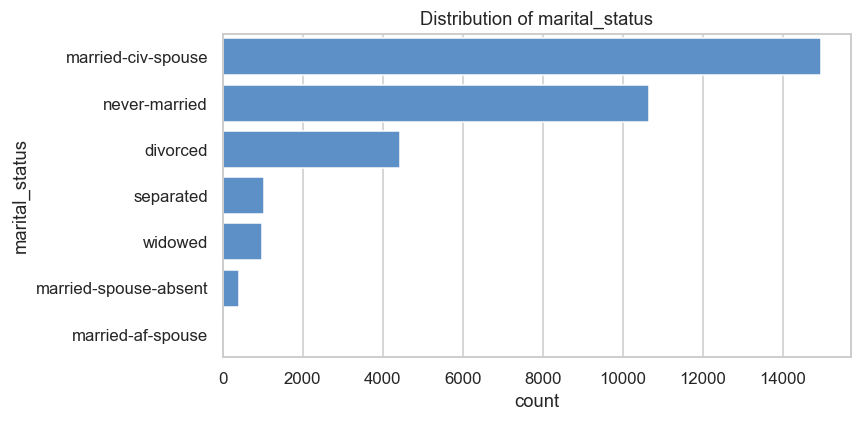

In [85]:
plt.figure(figsize=(8,4))

order = df_eda['marital_status'].value_counts().index

sns.countplot(
    data=df_eda,
    y='marital_status',
    order=order,
    color='#4a90d9'
)

plt.title('Distribution of marital_status')
plt.tight_layout()
plt.show()

### Analysis

The distribution of marital status is highly concentrated in a few categories. The largest group is Married-civ-spouse, accounting for 46.01% of all individuals, indicating that nearly half of the dataset consists of married people living with their spouses.

The second-largest category is Never-married (32.78%), followed by Divorced (13.65%). Together, these three categories represent more than 92% of all observations, while the remaining categories account for only a small proportion of the dataset.

Categories such as Separated (3.15%), Widowed (3.05%), Married-spouse-absent (1.28%), and Married-AF-spouse (0.07%) are relatively rare. This indicates a clear imbalance in the distribution of marital status.

## Section 6 — Univariate Analysis of Occupation

In [86]:
# Frequency table for occupation

freq_table = pd.DataFrame({
    'count': df_eda['occupation'].value_counts(),
    'percentage': (df_eda['occupation'].value_counts(normalize=True)*100).round(2)
})

freq_table.head(15)

,count,percentage
occupation,,
prof-specialty,5978,18.37
craft-repair,4093,12.58
exec-managerial,4065,12.49
adm-clerical,3768,11.58
sales,3649,11.22
other-service,3291,10.12
machine-op-inspct,2000,6.15
transport-moving,1597,4.91
handlers-cleaners,1369,4.21


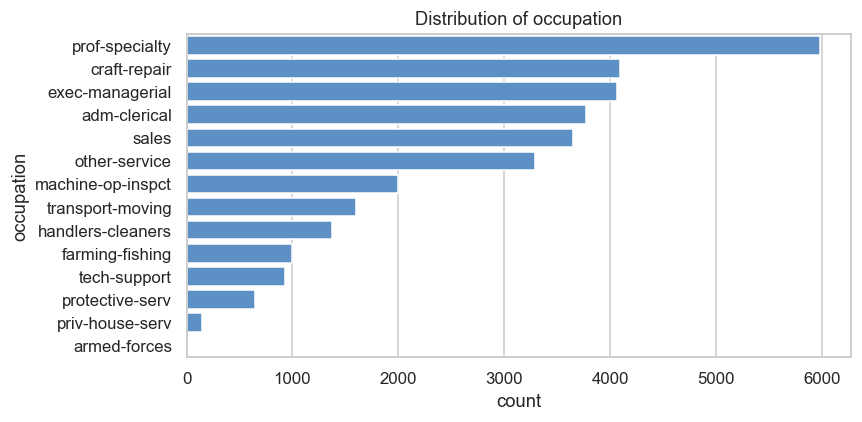

In [87]:
plt.figure(figsize=(8,4))

order = df_eda['occupation'].value_counts().index

sns.countplot(
    data=df_eda,
    y='occupation',
    order=order,
    color='#4a90d9'
)

plt.title('Distribution of occupation')
plt.tight_layout()
plt.show()


### Analysis

The occupation variable exhibits considerable diversity across job categories. The largest category is Prof-specialty, accounting for 18.37% of all observations, followed by Craft-repair (12.58%) and Exec-managerial (12.49%). Several other occupations, including Adm-clerical (11.58%), Sales (11.22%), and Other-service (10.12%), also represent substantial portions of the workforce.

Together, these major occupation groups account for the majority of individuals in the dataset, indicating that employment is concentrated within a relatively small number of occupational categories. In contrast, occupations such as Priv-house-serv (0.45%) and Armed-forces (0.03%) are extremely rare and contain only a limited number of observations.

## Section 7 — Univariate Analysis of Relationship

In [88]:
# Frequency table for relationship

freq_table = pd.DataFrame({
    'count': df_eda['relationship'].value_counts(),
    'percentage': (df_eda['relationship'].value_counts(normalize=True)*100).round(2)
})

freq_table.head(15)

,count,percentage
relationship,,
husband,13185,40.53
not-in-family,8292,25.49
own-child,5063,15.56
unmarried,3445,10.59
wife,1568,4.82
other-relative,981,3.02


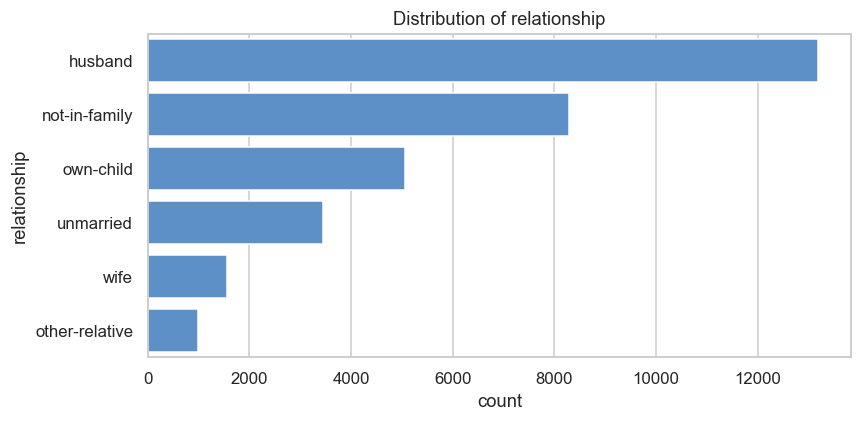

In [89]:
plt.figure(figsize=(8,4))

order = df_eda['relationship'].value_counts().index

sns.countplot(
    data=df_eda,
    y='relationship',
    order=order,
    color='#4a90d9'
)

plt.title('Distribution of relationship')
plt.tight_layout()
plt.show()

### Analysis

The relationship variable is dominated by the Husband category, which accounts for 40.53% of all observations. This is followed by Not-in-family (25.49%) and Own-child (15.56%). Together, these three categories represent more than 80% of the dataset.

Other relationship categories, including Unmarried (10.59%), Wife (4.82%), and Other-relative (3.02%), occur much less frequently. The distribution is therefore noticeably imbalanced, with a small number of relationship types accounting for the majority of individuals.

The high proportion of individuals classified as Husband suggests that a substantial segment of the dataset consists of married adults who serve as the primary reference person within their households. In contrast, categories such as Own-child and Not-in-family may represent younger individuals or people living in different family arrangements.

## Section 8 — Univariate Analysis of Race

In [90]:
# Frequency table for race

freq_table = pd.DataFrame({
    'count': df_eda['race'].value_counts(),
    'percentage': (df_eda['race'].value_counts(normalize=True)*100).round(2)
})

freq_table.head(15)

,count,percentage
race,,
white,27792,85.42
black,3122,9.60
asian-pac-islander,1038,3.19
amer-indian-eskimo,311,0.96
other,271,0.83


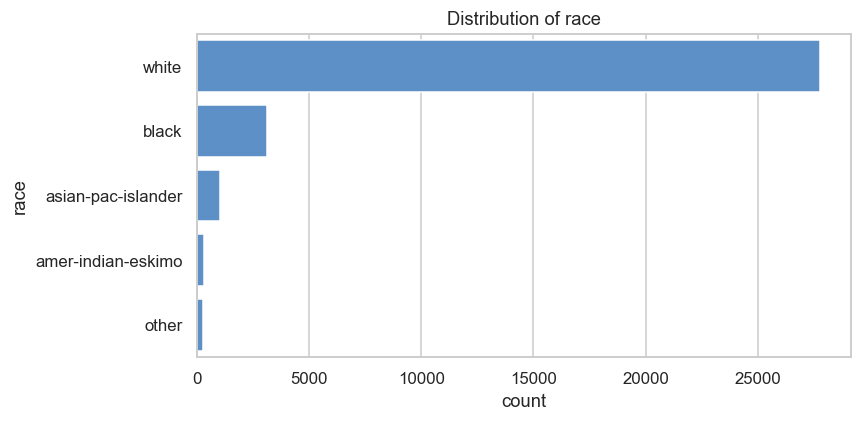

In [91]:
plt.figure(figsize=(8,4))

order = df_eda['race'].value_counts().index

sns.countplot(
    data=df_eda,
    y='race',
    order=order,
    color='#4a90d9'
)

plt.title('Distribution of race')
plt.tight_layout()
plt.show()

### Analysis

The distribution of race is highly imbalanced. The White category dominates the dataset, accounting for 85.42% of all observations. The second-largest group is Black (9.60%), while Asian-Pac-Islander represents only 3.19% of the sample.

The remaining categories, Amer-Indian-Eskimo (0.96%) and Other (0.83%), contain relatively few observations. Together, these two groups account for less than 2% of the dataset.

This distribution indicates that the dataset is heavily concentrated in a single racial category, with minority groups being substantially underrepresented. Such imbalance should be considered when interpreting statistical results, as patterns observed for smaller groups may be less stable due to the limited number of observations.


## Section 9 — Univariate Analysis of Sex

In [92]:
# Frequency table for sex

freq_table = pd.DataFrame({
    'count': df_eda['sex'].value_counts(),
    'percentage': (df_eda['sex'].value_counts(normalize=True)*100).round(2)
})

freq_table.head(15)

,count,percentage
sex,,
male,21773,66.92
female,10761,33.08


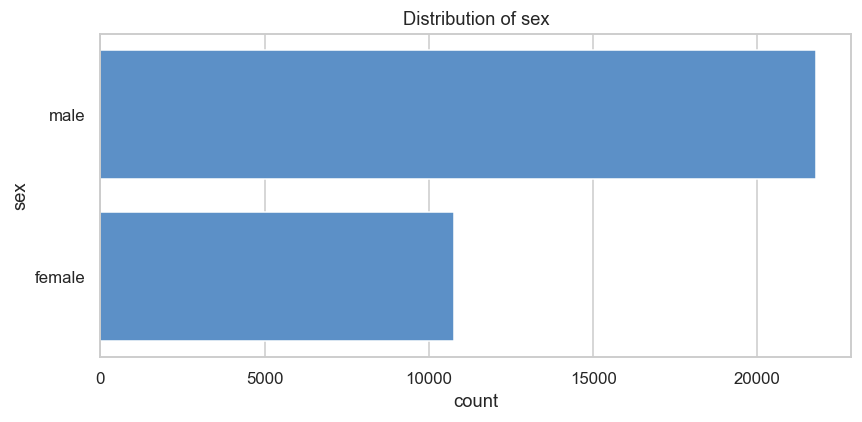

In [93]:
plt.figure(figsize=(8,4))

order = df_eda['sex'].value_counts().index

sns.countplot(
    data=df_eda,
    y='sex',
    order=order,
    color='#4a90d9'
)

plt.title('Distribution of sex')
plt.tight_layout()
plt.show()

### Analysis

The distribution of sex is moderately imbalanced, with Male individuals accounting for 66.92% of the dataset and Female individuals accounting for 33.08%. This indicates that approximately two-thirds of the observations are male, while one-third are female.

Although both categories are well represented, males constitute a substantially larger proportion of the sample. This imbalance should be taken into account when interpreting descriptive statistics and modelling results, as overall patterns may be influenced more heavily by the male population.

## Section 10 — Univariate Analysis of Native_country

In [94]:
# Frequency table for native_country

freq_table = pd.DataFrame({
    'count': df_eda['native_country'].value_counts(),
    'percentage': (df_eda['native_country'].value_counts(normalize=True)*100).round(2)
})

freq_table.head(15)

,count,percentage
native_country,,
united-states,29732,91.39
mexico,639,1.96
philippines,198,0.61
germany,137,0.42
canada,121,0.37
puerto-rico,114,0.35
el-salvador,106,0.33
india,100,0.31
cuba,95,0.29


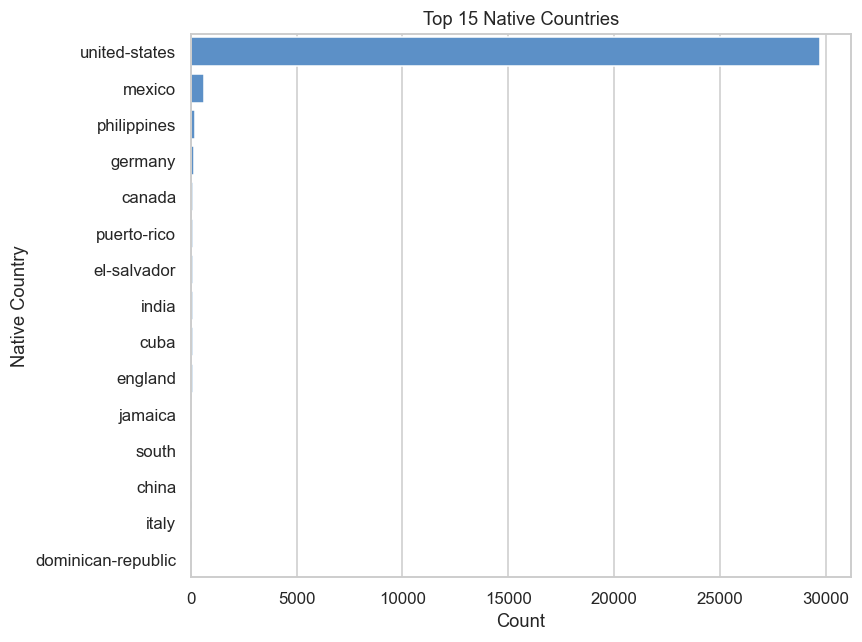

In [95]:
top15 = df_eda['native_country'].value_counts().head(15)

plt.figure(figsize=(8,6))

sns.barplot(
    x=top15.values,
    y=top15.index,
    color='#4a90d9'
)

plt.title('Top 15 Native Countries')
plt.xlabel('Count')
plt.ylabel('Native Country')

plt.tight_layout()
plt.show()

### Analysis

The distribution of native country is extremely imbalanced. As shown in the chart, the United States overwhelmingly dominates the dataset, accounting for 91.39% of all observations. This indicates that the dataset primarily represents individuals from the United States.

Among the non-U.S. categories, Mexico is the second-largest group, representing only 1.96% of the sample. Other countries, including the Philippines (0.61%), Germany (0.42%), Canada (0.37%), Puerto Rico (0.35%), and India (0.31%), contribute only a small proportion of observations.

The substantial dominance of the United States suggests that the dataset largely reflects the demographic and socioeconomic characteristics of the U.S. workforce. In contrast, most foreign-country categories contain relatively few observations, which may limit the reliability of statistical comparisons involving those groups.

Therefore, any country-level analysis should be interpreted with caution, particularly for categories with very small sample sizes. Nevertheless, native country may still provide useful insights when exploring differences in income and employment outcomes across population groups.

# 3. Bivariate Analysis

This section examines the relationship between each available predictor variable and income, following the approach in the example code. The target variable itself is not analysed against itself. For categorical variables, the main measure is the within-category share earning `>50K`, visualised using different methods, including **high-income rate bar charts**, **100% stacked bar charts**, and **heatmaps**. For numerical variables, distributions are compared across the two income groups, using **box plots** and **violin plots** for visualisation.

This section also serves to validate our **hypothesis**:
1. Significant income distribution differences may exist across demographic groups.
2. Education level, occupation, and working hours will be among the most influential factors affecting annual income.

## Section 1 - Numeric Variables

In [263]:
# Create a numeric version of the target for bivariate rate calculations.

df_eda = df_eda.copy()
df_eda['income'] = df_eda['income'].astype(str).str.strip().str.lower()
df_eda['income_binary'] = (df_eda['income'] == '>50k').astype(int)

print('Income categories:')
print(df_eda['income'].value_counts())

print('\nOverall high-income rate:')
print(f"{df_eda['income_binary'].mean() * 100:.2f}%")

Income categories:
income
<=50k    24696
>50k      7838
Name: count, dtype: int64

Overall high-income rate:
24.09%


### Section 1.1 - Age vs. Income

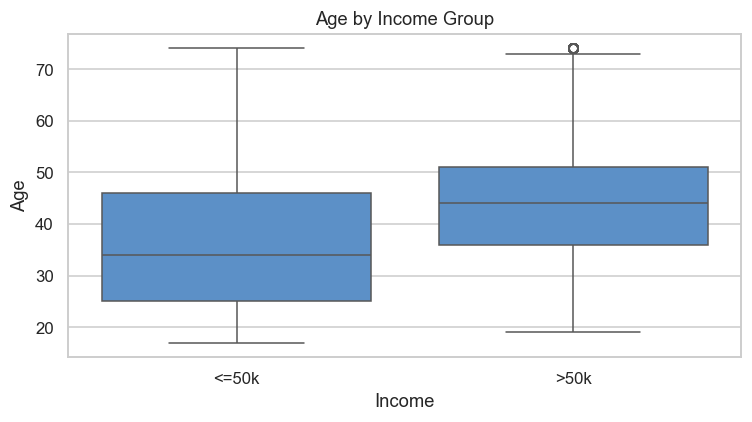

,count,mean,std,min,25%,50%,75%,max
income,,,,,,,,
<=50k,24696.0,36.73,13.84,17.0,25.0,34.0,46.0,74.0
>50k,7838.0,44.22,10.40,19.0,36.0,44.0,51.0,74.0


In [154]:
plt.figure(figsize=(7, 4))

sns.boxplot(
    data=df_eda,
    x='income',
    y='age',
    order=['<=50k', '>50k'],
    color='#4a90d9'
)

plt.title('Age by Income Group')
plt.xlabel('Income')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

df_eda.groupby('income')['age'].describe().round(2)

### Analysis 

Individuals earning more than 50K tend to be noticeably older than those earning 50K or less. The average age of the >50K group is 44.2 years, compared with 36.7 years for the <=50K group. The median age also increases from 34 to 44 years. This pattern suggests that age, which may reflect accumulated work experience and career progression, is positively associated with income. However, there is still substantial overlap between the two distributions, indicating that age alone is not sufficient to distinguish high-income from low-income individuals.

### Section 1.2 - Hours per Week vs. Income

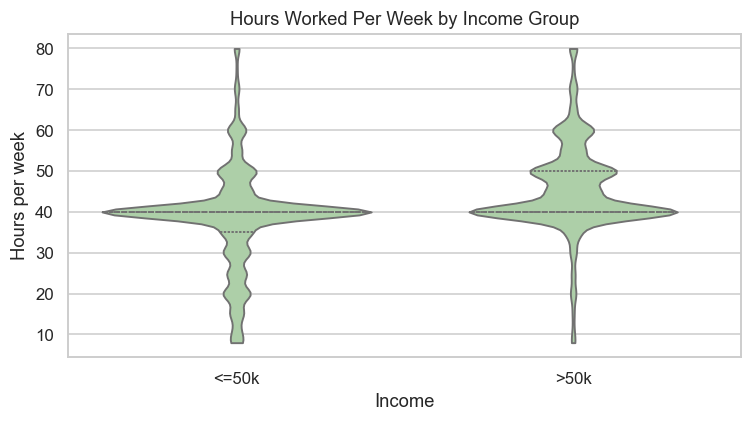

,count,mean,std,min,25%,50%,75%,max
income,,,,,,,,
<=50k,24696.0,38.81,11.91,8.0,35.0,40.0,40.0,80.0
>50k,7838.0,45.39,10.57,8.0,40.0,40.0,50.0,80.0


In [155]:
plt.figure(figsize=(7, 4))

sns.violinplot(
    data=df_eda,
    x='income',
    y='hours_per_week',
    order=['<=50k', '>50k'],
    inner='quartile',
    color='#a8d5a2',
    cut=0
)

plt.title('Hours Worked Per Week by Income Group')
plt.xlabel('Income')
plt.ylabel('Hours per week')
plt.tight_layout()
plt.show()

df_eda.groupby('income')['hours_per_week'].describe().round(2)

### Analysis

Individuals earning more than 50K tend to work more hours per week. The average number of weekly working hours increases from 38.8 hours in the <=50K group to 45.4 hours in the >50K group. The upper quartile also shifts from 40 to 50 hours, indicating that higher-income individuals are more likely to work beyond a standard full-time schedule. Nevertheless, both groups remain heavily concentrated around 40 hours per week, suggesting that working hours contribute useful information.

## Section 2 - Categorical Variables

In [164]:
# Helper functions for repeated income comparisons

if 'income_binary' not in df_eda.columns:
    df_eda['income'] = df_eda['income'].astype(str).str.strip().str.lower()
    df_eda['income_binary'] = (df_eda['income'] == '>50k').astype(int)
    
def categorical_income_summary(column, min_count=1):
    summary = (
        df_eda.groupby(column)['income_binary']
              .agg(count='size', high_income_rate='mean')
              .sort_values('high_income_rate', ascending=False)
    )
    return summary.query('count >= @min_count')
    
def plot_categorical_income_rate(column, title, min_count=1, top_n=None):
    summary = categorical_income_summary(column, min_count=min_count)

    if top_n is not None:
        common_categories = df_eda[column].value_counts().head(top_n).index
        summary = summary.loc[summary.index.intersection(common_categories)]
        summary = summary.sort_values('high_income_rate', ascending=False)

    plt.figure(figsize=(9, max(4, 0.35 * len(summary))))
    sns.barplot(
        data=summary.reset_index(),
        y=column,
        x='high_income_rate',
        color='#4a90d9'
    )
    plt.title(title)
    plt.xlabel('Share earning >50K')
    plt.ylabel(column)
    plt.xlim(0, max(0.6, summary['high_income_rate'].max() + 0.05))
    plt.gca().xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x:.0%}')
    )
    plt.tight_layout()
    plt.show()

    display_summary = summary.copy()
    display_summary['high_income_rate'] = (
        display_summary['high_income_rate'] * 100
    ).round(2)
    return display_summary

### Section 2.1 - Workclass vs. Income

In [183]:
workclass_income = pd.crosstab(
    df_eda['workclass'],
    df_eda['income'],
    normalize='index'
) * 100

workclass_income.round(2)

income,<=50k,>50k
workclass,,
federal-gov,61.35,38.65
local-gov,70.52,29.48
never-worked,100.00,0.00
private,78.98,21.02
self-emp-inc,44.27,55.73
self-emp-not-inc,71.50,28.50
state-gov,72.80,27.20
without-pay,100.00,0.00


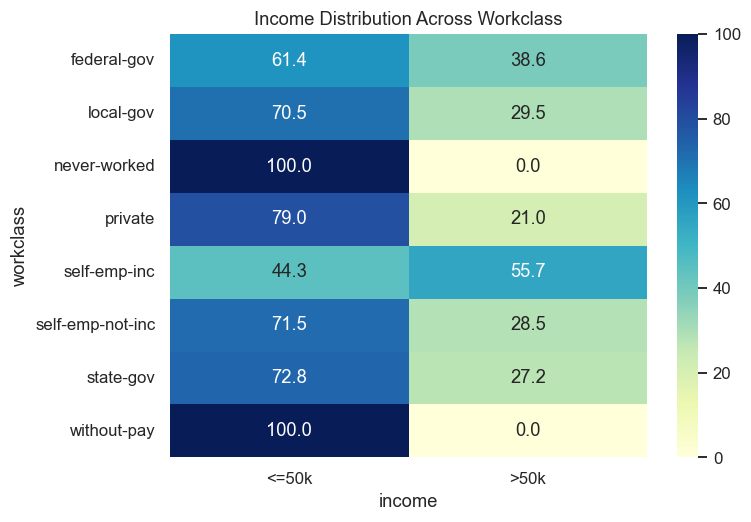

In [184]:
plt.figure(figsize=(7,5))

sns.heatmap(
    workclass_income,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu'
)

plt.title('Income Distribution Across Workclass')
plt.show()

### Analysis

Income levels vary considerably across workclass categories. The heatmap clearly shows that `self-emp-inc` workers have the highest proportion of high-income earners, with **55.7%** earning more than 50K. `federal-gov` employees follow with **38.7%** in the high-income group.

In contrast, `private` sector workers show a much lower high-income rate of only **21.0%**,. Other government employment categories, including `local-gov`, `state-gov`, and `self-emp-not-inc`, fall between these extremes.

Overall, the heatmap reveals a clear gradient: self-employed incorporated workers and federal government employees are most likely to earn above 50K, while private sector and other government workers have substantially lower high-income rates. These differences suggest that employment type is meaningfully associated with income outcomes.

### Section 2.2 - Education vs. Income

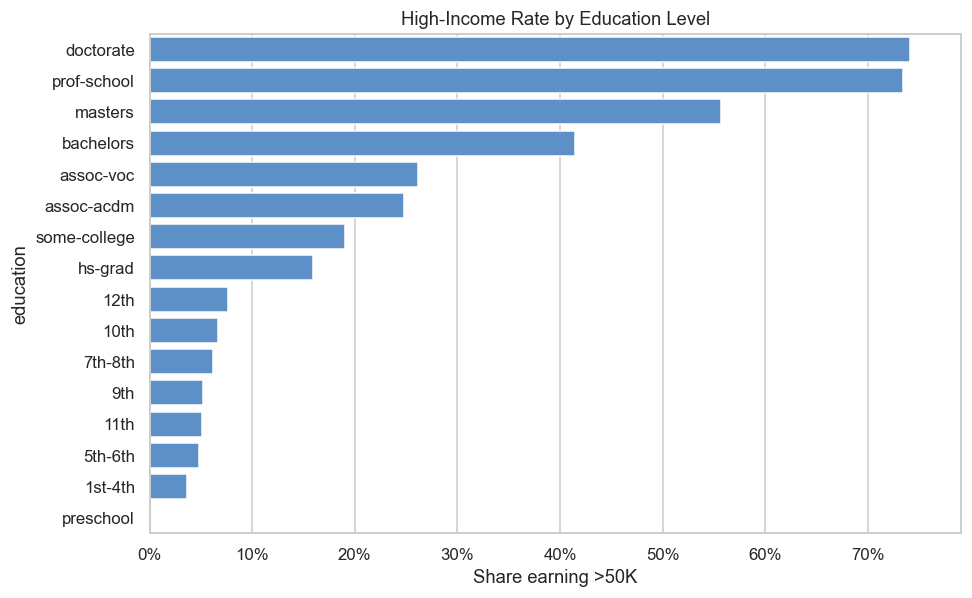

,count,high_income_rate
education,,
doctorate,413,74.09
prof-school,576,73.44
masters,1722,55.69
bachelors,5352,41.48
assoc-voc,1382,26.12
assoc-acdm,1067,24.84
some-college,7281,19.04
hs-grad,10493,15.95
12th,433,7.62


In [157]:
plot_categorical_income_rate(
    'education',
    'High-Income Rate by Education Level'
)

### Analysis

Education shows one of the strongest relationships with income in the dataset. Individuals with advanced qualifications have substantially higher rates of earning more than 50K, including Doctorate (74.1%), Professional School (73.4%), and Master's degrees (55.7%). In contrast, high-income rates remain below 10% for most education levels below high school completion. The steady increase in income rates across education levels suggests that educational attainment is a highly informative predictor of income and is likely to play an important role in subsequent modelling.

### Section 2.3 - Marital Status vs. Income

In [180]:
marital_income = pd.crosstab(
    df_eda['marital_status'],
    df_eda['income'],
    normalize='index'
) * 100

marital_income.round(2)

income,<=50k,>50k
marital_status,,
divorced,89.57,10.43
married-af-spouse,56.52,43.48
married-civ-spouse,55.31,44.69
married-spouse-absent,91.87,8.13
never-married,95.40,4.60
separated,93.56,6.44
widowed,91.44,8.56


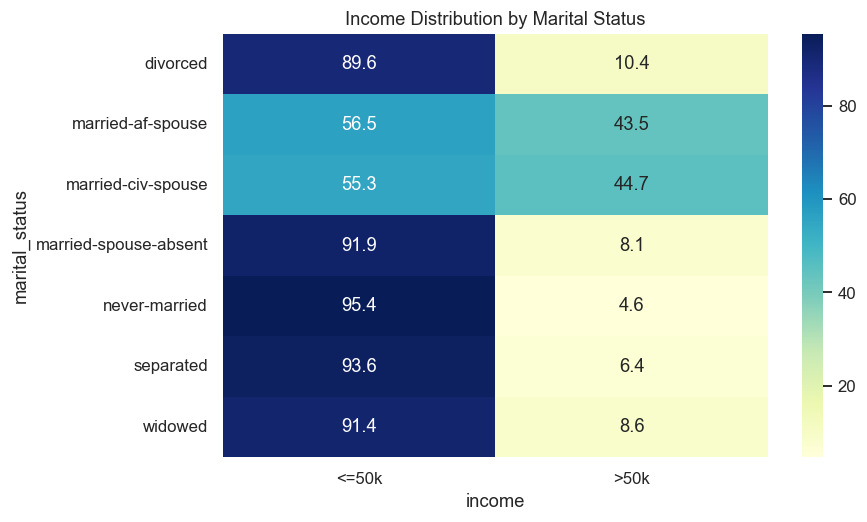

In [182]:
plt.figure(figsize=(8,5))

sns.heatmap(
    marital_income,
    annot=True,
    fmt='.1f',
    cmap='YlGnBu'
)

plt.title('Income Distribution by Marital Status')
plt.show()

### Analysis

Marital status is strongly associated with income. Nearly 45% of individuals in the Married-civ-spouse category earn more than 50K, compared with only 4.6% among those who have never married. Divorced, separated, widowed, and spouse-absent categories also show relatively low high-income rates. These differences may reflect variations in age, career stage, household composition, and financial circumstances. Although marital status appears highly informative, part of its relationship with income may overlap with other demographic and socioeconomic variables.

### Section 2.4 - Occupation vs. Income

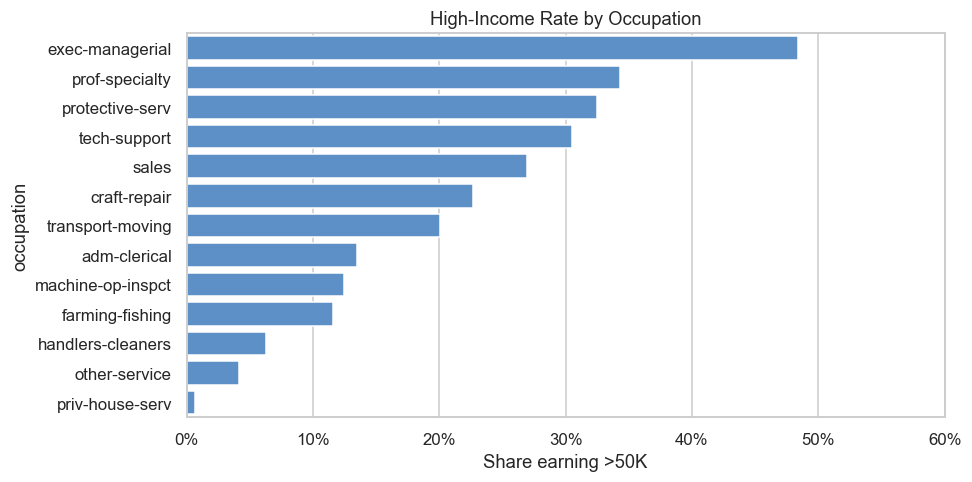

,count,high_income_rate
occupation,,
exec-managerial,4065,48.41
prof-specialty,5978,34.28
protective-serv,649,32.51
tech-support,927,30.53
sales,3649,26.91
craft-repair,4093,22.70
transport-moving,1597,20.04
adm-clerical,3768,13.46
machine-op-inspct,2000,12.45


In [166]:
plot_categorical_income_rate(
    'occupation',
    'High-Income Rate by Occupation',
    min_count=50
)

### Analysis

Occupation exhibits substantial variation in income outcomes. Executive-managerial occupations have the highest high-income rate (48.4%), followed by professional-specialty roles (34.3%), protective services (32.5%), and technical support positions (30.5%). In contrast, service-oriented occupations such as other-service (4.2%) and private-house-service (0.7%) show very low proportions of high-income earners. These findings indicate that occupation captures important differences in skill requirements, responsibilities, and compensation levels, making it one of the strongest candidate predictors of income.

### Section 2.5 - Relationship vs. Income

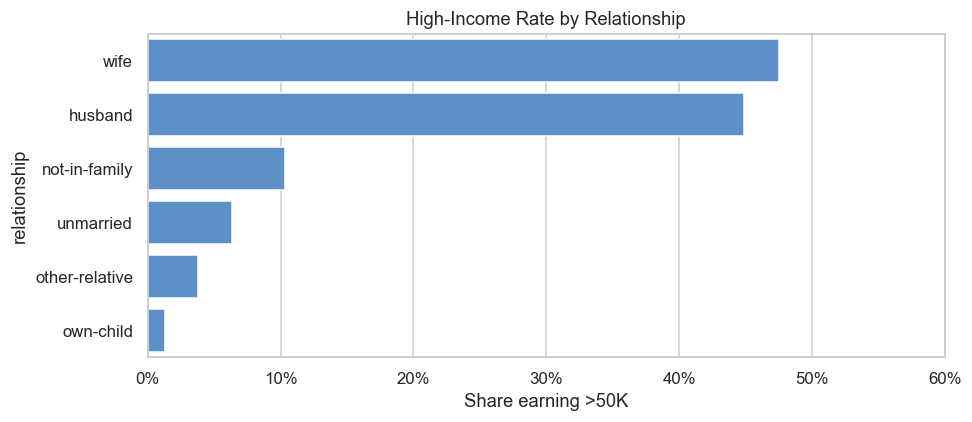

,count,high_income_rate
relationship,,
wife,1568,47.51
husband,13185,44.86
not-in-family,8292,10.32
unmarried,3445,6.33
other-relative,981,3.77
own-child,5063,1.32


In [103]:
plot_categorical_income_rate(
    'relationship',
    'High-Income Rate by Relationship'
)

### Analysis

Relationship status is closely associated with income. Individuals classified as wife (47.5%) and husband (44.9%) have substantially higher high-income rates than those in categories such as own-child (1.3%), other-relative (3.8%), and unmarried (6.3%). This pattern is likely related to differences in age, marital status, and household roles. Because relationship categories overlap conceptually with marital status, some of the observed effects may reflect similar underlying social and demographic factors.

### Section 2.6 - Race vs. Income

In [201]:
race_income = pd.crosstab(
    df_eda['race'],
    df_eda['income'],
    normalize='index'
)

race_income.round(2)

income,<=50k,>50k
race,,
amer-indian-eskimo,0.88,0.12
asian-pac-islander,0.73,0.27
black,0.88,0.12
other,0.91,0.09
white,0.74,0.26


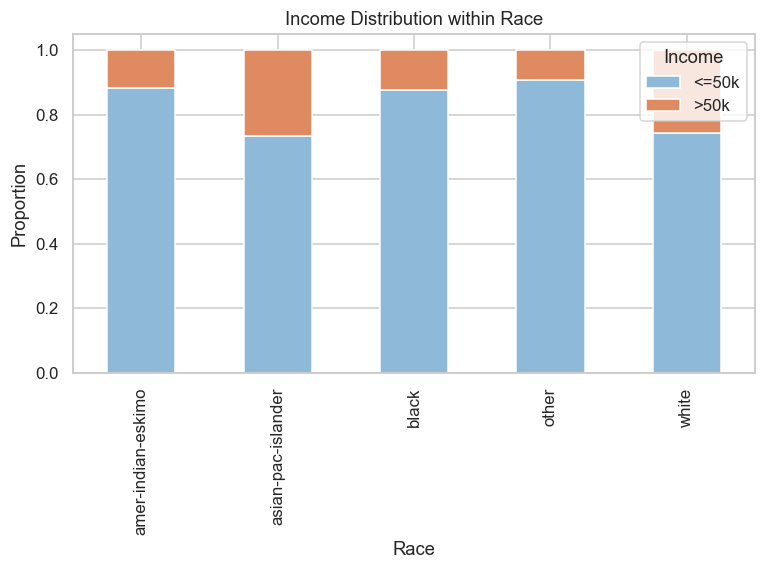

In [204]:
race_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(8,4),
    color=['#8fb9d9', '#e08a62']
)

plt.title('Income Distribution within Race')
plt.ylabel('Proportion')
plt.xlabel('Race')

plt.legend(title='Income')

plt.show()

### Analysis

High-income rates differ across race categories. Asian-Pac-Islander (26.6%) and White (25.6%) individuals have higher proportions of income above 50K than Black (12.4%), Amer-Indian-Eskimo (11.6%), and Other (9.2%) groups. And the stacked bar chart also provides a clear comparison of income distribution across racial groups. While these differences are visible in the dataset, they should be interpreted cautiously.

### Section 2.7 - Sex vs. Income

In [205]:
sex_income = pd.crosstab(
    df_eda['sex'],
    df_eda['income'],
    normalize='index'
)

sex_income.round(2)

income,<=50k,>50k
sex,,
female,0.89,0.11
male,0.69,0.31


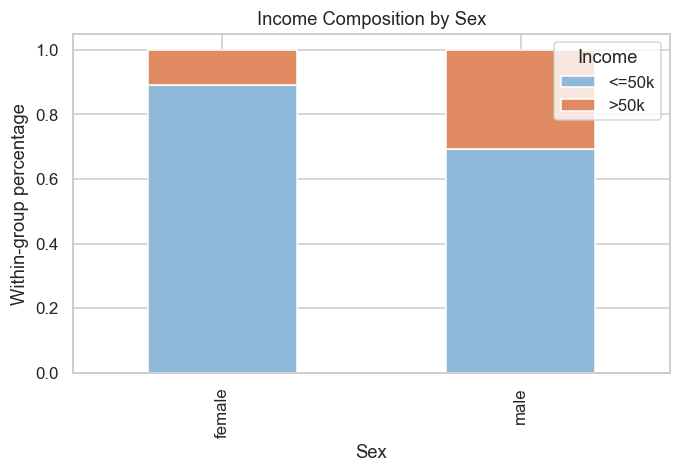

In [209]:
ax = sex_income_table.plot(
    kind='bar',
    stacked=True,
    figsize=(7, 4),
    color=['#8fb9d9', '#e08a62']
)

plt.title('Income Composition by Sex')
plt.xlabel('Sex')
plt.ylabel('Within-group percentage')

plt.legend(title='Income', loc='upper right')

plt.show()

### Analysis

The proportion of individuals earning more than 50K differs substantially by sex. Approximately 30.6% of males belong to the high-income group, compared with 11.0% of females. This is one of the largest differences observed among the categorical variables. 

The stacked bar chart also clearly illustrates the income composition by sex. Visually, the orange segment representing high-income earners is noticeably larger for males, while the blue segment dominates the female bar, indicating a substantial gender gap in income outcomes.

### Section 2.8 - Native Country vs. Income

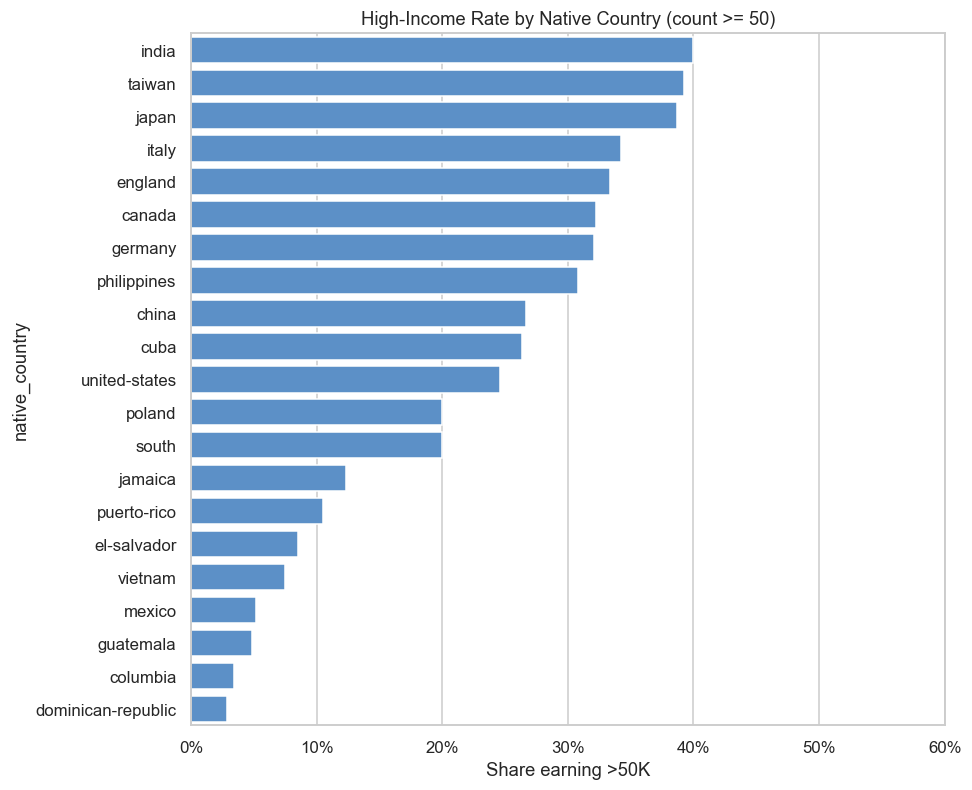

,count,high_income_rate
native_country,,
india,100,40.00
taiwan,51,39.22
japan,62,38.71
italy,73,34.25
england,90,33.33
canada,121,32.23
germany,137,32.12
philippines,198,30.81
china,75,26.67


In [107]:
# Native country has many small categories. The plot keeps categories with at least
# 50 records to avoid over-interpreting unstable percentages.

plot_categorical_income_rate(
    'native_country',
    'High-Income Rate by Native Country (count >= 50)',
    min_count=50
)

### Analysis

Native country shows some variation in high-income rates. Among countries with at least 50 observations, India (40.0%), Taiwan (39.2%), and Japan (38.7%) have the highest proportions of individuals earning more than 50K. The United States, which represents the vast majority of observations, has a high-income rate of 24.6%. However, many countries are represented by relatively small samples, making their estimated rates more sensitive to random variation. For predictive modelling, grouping less frequent countries or applying appropriate encoding techniques may help reduce instability caused by sparse categories.

## Section 3 - Correlation with Income

Because `age` and `hours_per_week` are continuous variables, their association with income is measured using **correlation coefficients**, consistent with the approach used in *03_bivariate_analysis.ipynb*. In contrast, `capital_gain_flag` and `capital_loss_flag` are binary variables, so **Cramer's V** is used to measure their association with income. All other categorical variables are also evaluated using **Cramer's V**.

Cramér's V was used to measure the strength of association between each categorical variable and income. Unlike the previous visualisations, which show differences in income distributions across categories, Cramér's V provides a single numerical measure of association ranging from 0 (no association) to 1 (perfect association).

In [290]:
numeric_bivariate_cols = [
    'age',
    'hours_per_week',
    'income_binary'
]

corr = df_eda[numeric_bivariate_cols].corr()
corr.round(3)

,age,hours_per_week,income_binary
age,1.000,0.076,0.237
hours_per_week,0.076,1.000,0.236
income_binary,0.237,0.236,1.000


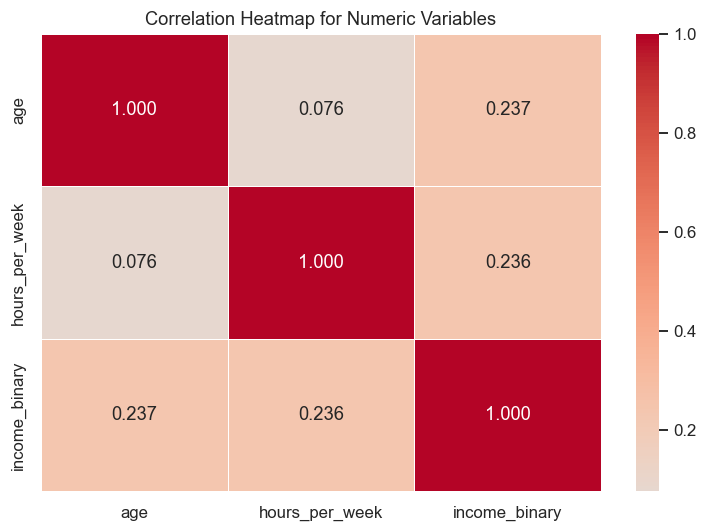

In [291]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    corr,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title('Correlation Heatmap for Numeric Variables')
plt.tight_layout()
plt.show()

### Analysis

Age and hours worked per week both show positive correlations with income_binary, with correlation coefficients of **0.237** and **0.236**, respectively. This indicates that older individuals and those who work longer hours are more likely to belong to the high-income group. However, both correlations remain relatively weak, suggesting that neither variable alone can strongly explain differences in income.

The heatmap also shows that the correlation between age and hours worked per week is only **0.076**, indicating very little linear relationship between these two predictors. Overall, the low correlations among the numerical variables suggest that multicollinearity is unlikely to be a major concern for these features.

In [213]:
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(x, y):
    table = pd.crosstab(x, y)

    chi2 = chi2_contingency(table)[0]

    n = table.sum().sum()

    r, k = table.shape

    return np.sqrt(
        chi2 /
        (n * (min(k - 1, r - 1)))
    )

In [289]:
binary_vars = [
    'capital_gain_flag',
    'capital_loss_flag'
]

binary_results = []

for col in binary_vars:

    score = cramers_v(
        df_eda[col],
        df_eda['income']
    )

    binary_results.append(
        [col, score]
    )

binary_df = pd.DataFrame(
    binary_results,
    columns=['Variable', 'Cramers_V']
)

binary_df.sort_values(
    'Cramers_V',
    ascending=False
)

,Variable,Cramers_V
0,capital_gain_flag,0.266036
1,capital_loss_flag,0.138506


In [215]:
categorical_vars = [
    'workclass',
    'education',
    'marital_status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native_country'
]

cramer_results = []

for col in categorical_vars:

    score = cramers_v(
        df_eda[col],
        df_eda['income']
    )

    cramer_results.append(
        [col, score]
    )

cramer_df = pd.DataFrame(
    cramer_results,
    columns=['Variable', 'Cramers_V']
)

cramer_df = cramer_df.sort_values(
    'Cramers_V',
    ascending=False
)

cramer_df

,Variable,Cramers_V
4,relationship,0.453508
2,marital_status,0.447306
1,education,0.368878
3,occupation,0.313511
6,sex,0.215865
0,workclass,0.168388
5,race,0.100852
7,native_country,0.098455


### Analysis

Cramer's V results show substantial differences in the strength of association between categorical variables and income. Among the binary variables, **capital_gain_flag (V = 0.266)** exhibits a noticeably stronger relationship with income than **capital_loss_flag (V = 0.139)**, suggesting that individuals reporting capital gains are more likely to belong to the high-income group.

Among the remaining categorical variables, the strongest associations are observed for **relationship (V = 0.454)** and **marital_status (V = 0.447)**, followed by **education (V = 0.369)** and **occupation (V = 0.314)**. These variables show clear differences in income distribution across categories and appear to be important predictors of income.

Moderate associations are observed for **capital_gain_flag**, **sex (V = 0.216)**, and **workclass (V = 0.168)**, while **capital_loss_flag**, **race (V = 0.101)**, and **native_country (V = 0.098)** exhibit relatively weaker relationships with income.

Overall, the results suggest that family-related characteristics, education level, and occupation provide the most information for distinguishing between high-income and low-income individuals in this dataset.

# 4. Multivariate Analysis

In this section, based on the example code in `03_bivariate_analysis.ipynb`, we propose new hypotheses to investigate the relationships between numerical variables and to test for Simpson's paradox

## Section 1 -Age, Hours_per_week and Income

- **Hypothesis:** A negative correlation exists between age and weekly working hours—two numerical variables—and this relationship changes when an additional variable is introduced.
- **Visualise:** use a scatter plot with `age` on the x-axis, `hours_per_week` on the y-axis, and `income` shown by colour.

In [246]:
print(
    "Overall correlation:",
    round(
        df_eda['age'].corr(df_eda['hours_per_week']),
        3
    )
)

print("\nCorrelation within income groups:")

print(
    df_eda.groupby('income')[['age','hours_per_week']]
          .apply(
              lambda g:
              g['age'].corr(g['hours_per_week'])
          )
          .round(3)
)

Overall correlation: 0.076

Correlation within income groups:
income
<=50k    0.053
>50k    -0.128
dtype: float64


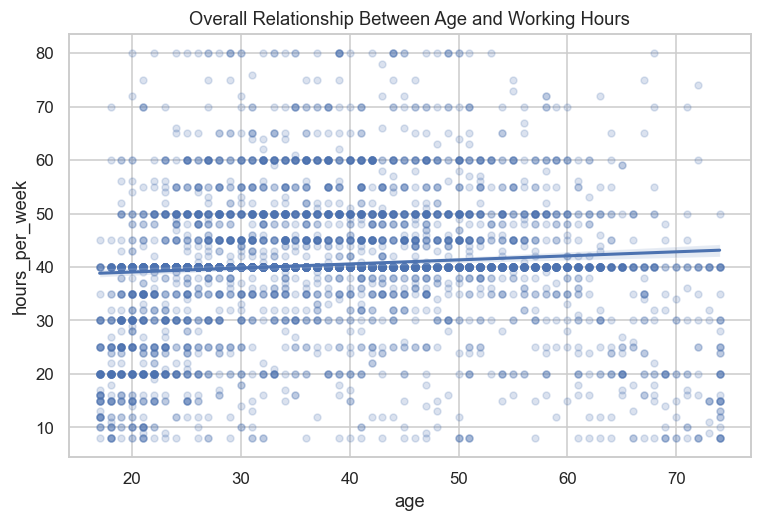

In [285]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=scatter_sample,
    x='age',
    y='hours_per_week',
    scatter_kws={
        'alpha':0.2,
        's':20
    },
    line_kws={
        'linewidth':2
    }
)

plt.title(
    'Overall Relationship Between Age and Working Hours'
)

plt.show()

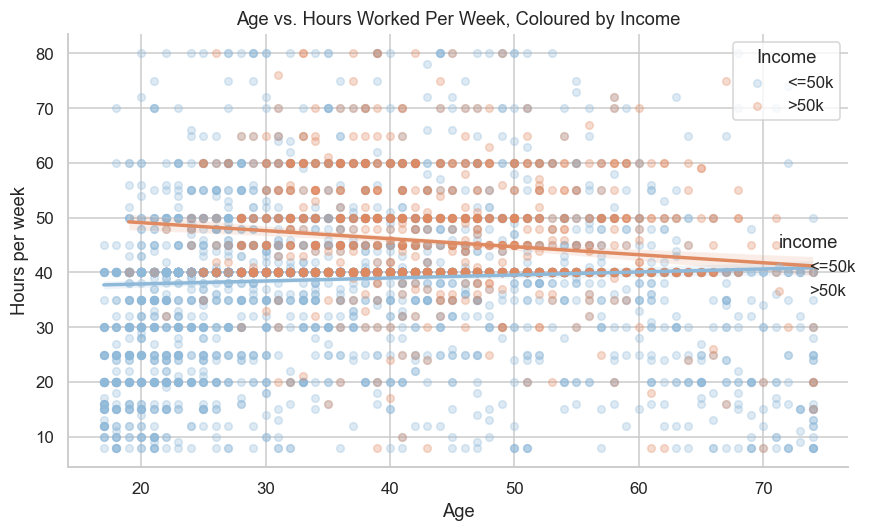

In [279]:
sns.lmplot(
    data=scatter_sample,
    x='age',
    y='hours_per_week',
    hue='income',
    hue_order=['<=50k','>50k'],
    palette={
        '<=50k':'#8fb9d9',
        '>50k':'#e08a62'
    },
    height=5,
    aspect=1.4,
    scatter_kws={
        'alpha':0.3,
        's':25
    }
)

plt.title('Age vs. Hours Worked Per Week, Coloured by Income')
plt.xlabel('Age')
plt.ylabel('Hours per week')
plt.legend(title='Income')
plt.tight_layout()
plt.show()

### Analysis

Based on the analysis of the two visualizations above:

The overall scatter plot shows almost no correlation between age and weekly working hours (r = 0.076). However, when income is introduced as a colour, two opposing patterns emerge. Among low-income individuals (≤50K), age and hours show a weak positive correlation (r = 0.053). Among high-income individuals (>50K), the correlation becomes weakly negative (r = -0.128). This is a classic example of **Simpson's paradox**: the sign of the correlation reverses when the data is stratified by a lurking variable—in this case, income.

The orange cluster (>50K) is concentrated around middle-aged adults (35–55 years) working 40–60 hours per week, supporting the idea that high-income individuals are more likely to be found among full-time or overtime workers in their middle years. The blue cluster (≤50K) is more spread out across age and working hours, with a slight positive trend.

## Section 2 - Sex, Education and Income

- **Hypothesis:** Education level influences the relationship between gender and income. This demonstrates that a lurking variable can alter the interpretation of a two-variable relationship.
- **Visualise:** compare the high-income rate by sex within each education category.

In [283]:
sex_income = (
    df_eda.groupby('sex')
          .agg(high_income_rate=('income_binary', 'mean'))
          .sort_values('high_income_rate', ascending=False)
)

sex_income

,high_income_rate
sex,
male,0.305838
female,0.109562


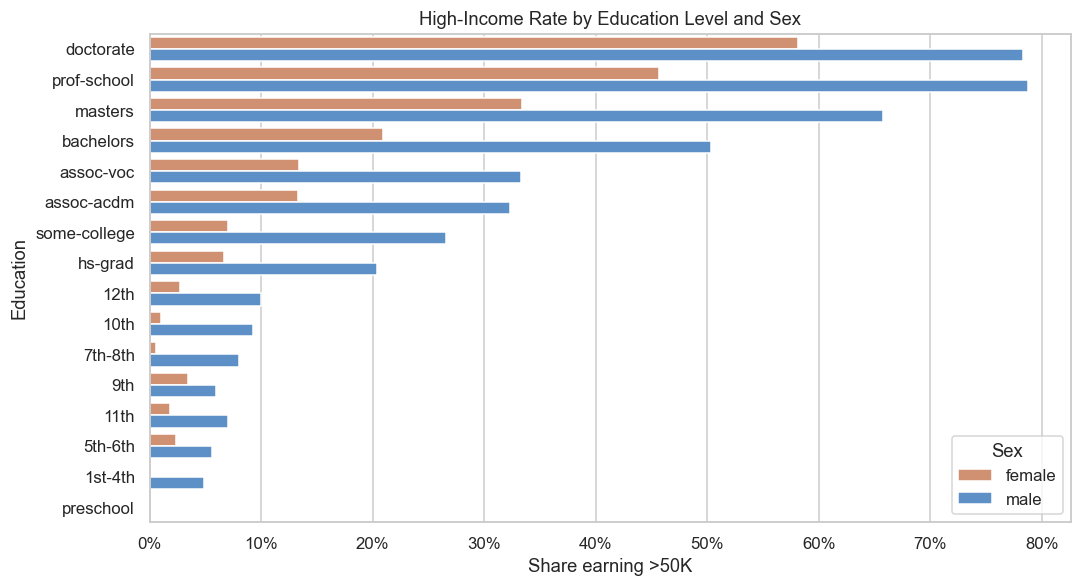

In [245]:
education_order = education_income.index.tolist()

plt.figure(figsize=(10, 5.5))

sns.barplot(
    data=sex_education_income,
    y='education',
    x='income_binary',
    hue='sex',
    order=education_order,
    palette=['#e08a62', '#4a90d9']
)

plt.title('High-Income Rate by Education Level and Sex')
plt.xlabel('Share earning >50K')
plt.ylabel('Education')
plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:.0%}')
)
plt.legend(title='Sex')
plt.tight_layout()
plt.show()

### Analysis

Overall, males have a much higher high-income rate (30.58%) than females (10.96%). After stratifying by education, males still outperform females in every education category—no Simpson's paradox. For instance, among bachelor's degree holders, the rates are 50.37% for males vs. 20.95% for females. However, the gender gap widens with education level: larger among highly educated groups (e.g., doctorate, master's) and smaller among lower-educated groups. Thus, education moderates the strength, but not the direction, of the gender-income relationship.

# 5. Data-Quality Hooks

EDA is also where we catch project-specific issues that can quietly affect interpretation or modelling.

## Hook A - target class imbalance

In [224]:
# Check target variable distribution

income_counts = df_eda['income'].value_counts()
income_pct = df_eda['income'].value_counts(normalize=True) * 100

income_summary = pd.DataFrame({
    'count': income_counts,
    'percentage': income_pct.round(2)
})

income_summary

,count,percentage
income,,
<=50k,24696,75.91
>50k,7838,24.09


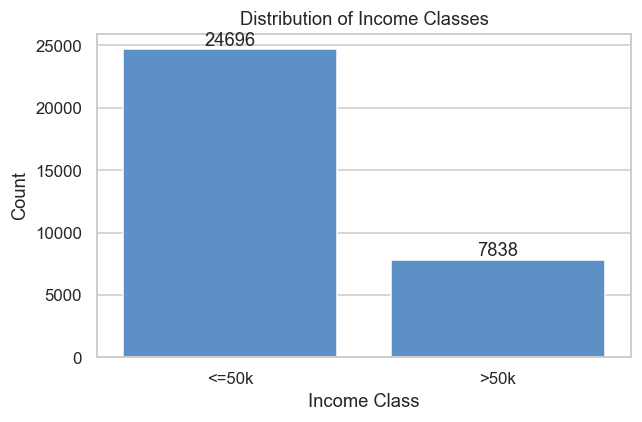

In [273]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(
    data=df_eda,
    x='income',
    color='#4a90d9'  
)

plt.title('Distribution of Income Classes')
plt.xlabel('Income Class')
plt.ylabel('Count')

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

 **Finding — the target is imbalanced.**

The `<=50K` class accounts for **75.91%** of all observations, while only **24.09%** belong to the `>50K` class. This imbalance means that overall accuracy can be misleading because a model may achieve a high score simply by favouring the majority class. As a result, future classification models should also be evaluated using metrics such as precision, recall, and F1-score rather than accuracy alone.

## Hook B - rare categorical groups

categorical_cols = df_eda.select_dtypes(include='object').columns.tolist()
rare_summary = []

for col in categorical_cols:
    counts = df_eda[col].value_counts()
    rare_count = int((counts < 50).sum())
    rare_summary.append({
        'column': col,
        'n_categories': int(counts.shape[0]),
        'rare_categories_under_50_rows': rare_count,
        'smallest_category': counts.index[-1],
        'smallest_count': int(counts.iloc[-1])
    })

rare_summary = pd.DataFrame(rare_summary).sort_values(
    ['rare_categories_under_50_rows', 'n_categories'],
    ascending=False
)
rare_summary

**Finding — some categories are extremely rare.**

Several categorical variables contain groups with very few observations. For example, `holand-netherlands` appears only once, `armed-forces` appears 9 times, and `married-af-spouse` appears 23 times. Statistics calculated for such small groups can appear unusually high or low simply because the sample size is tiny. Therefore, subgroup comparisons should always be interpreted together with the corresponding group counts.

## Hook C - skewed capital-gain and capital-loss indicators

,count_0,count_1,percentage_1
capital_gain_flag,29822,2712,8.34
capital_loss_flag,31015,1519,4.67


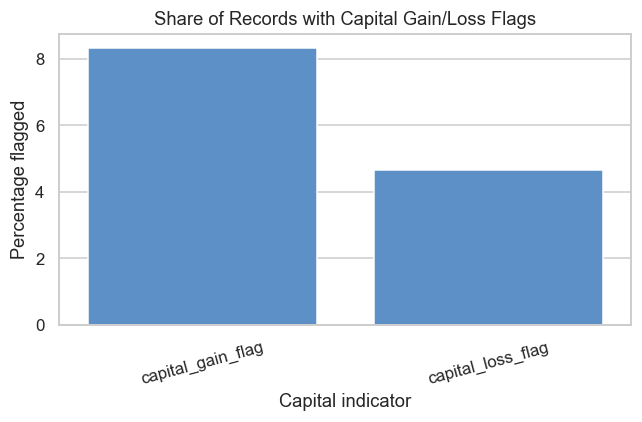

In [109]:
capital_cols = ['capital_gain_flag', 'capital_loss_flag']
capital_summary = pd.DataFrame({
    'count_0': [(df_eda[col] == 0).sum() for col in capital_cols],
    'count_1': [(df_eda[col] == 1).sum() for col in capital_cols],
    'percentage_1': [round((df_eda[col] == 1).mean() * 100, 2) for col in capital_cols]
}, index=capital_cols)

display(capital_summary)

plt.figure(figsize=(6, 4))
sns.barplot(
    data=capital_summary.reset_index().rename(columns={'index': 'capital_indicator'}),
    x='capital_indicator',
    y='percentage_1',
    color='#4a90d9'
)
plt.title('Share of Records with Capital Gain/Loss Flags')
plt.xlabel('Capital indicator')
plt.ylabel('Percentage flagged')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**Finding — capital gain and loss indicators are highly sparse.**

Only **8.34%** of individuals have a capital-gain flag, while just **4.67%** have a capital-loss flag. The vast majority of records contain no reported capital gain or loss. Although these variables may still be strongly associated with income, their highly uneven distribution means that results based on the flagged groups should be interpreted with caution.